# Informasi lingkungan

In [1]:
import os
import sys
import platform

print("Python       :", sys.version)
print("Sistem       :", platform.system())
print("Folder kerja :", os.getcwd())

Python       : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Sistem       : Windows
Folder kerja : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\notebooks


In [2]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [3]:
import sys
print(sys.executable)

c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\.venv\Scripts\python.exe


In [4]:
import cv2

print("OpenCV berhasil")
print("OpenCV version:", cv2.__version__)

OpenCV berhasil
OpenCV version: 5.0.0


# Memuat library

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import torch
import torchvision
import albumentations as A

from PIL import Image
from pathlib import Path

print("NumPy          :", np.__version__)
print("Pandas         :", pd.__version__)
print("OpenCV         :", cv2.__version__)
print("PyTorch        :", torch.__version__)
print("TorchVision    :", torchvision.__version__)
print("Albumentations :", A.__version__)
print("Semua library berhasil dimuat")

Matplotlib is building the font cache; this may take a moment.


NumPy          : 2.4.6
Pandas         : 3.0.5
OpenCV         : 5.0.0
PyTorch        : 2.13.0+cpu
TorchVision    : 0.28.0+cpu
Albumentations : 2.0.8
Semua library berhasil dimuat


# Memeriksa CPU atau GPU

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Perangkat yang digunakan :", device)
print("CUDA tersedia            :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nama GPU                  :", torch.cuda.get_device_name(0))
    print("Jumlah GPU                :", torch.cuda.device_count())
else:
    print("Training sementara menggunakan CPU")

Perangkat yang digunakan : cpu
CUDA tersedia            : False
Training sementara menggunakan CPU


# Menetapkan lokasi folder proyek

In [13]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATASET_DIR = PROJECT_DIR / "dataset"
MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

print("Current directory :", CURRENT_DIR)
print("Project directory :", PROJECT_DIR)
print("Dataset directory :", DATASET_DIR)
print("Models directory  :", MODELS_DIR)
print("Logs directory    :", LOGS_DIR)

Current directory : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\notebooks
Project directory : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification
Dataset directory : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset
Models directory  : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\models
Logs directory    : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs


In [14]:
from pathlib import Path

DATASET_DIR = PROJECT_DIR / "dataset"

print("Project :", PROJECT_DIR)
print("Dataset :", DATASET_DIR)
print("Dataset tersedia:", DATASET_DIR.exists())

Project : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification
Dataset : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset
Dataset tersedia: True


In [15]:
print("Isi folder dataset:\n")

for item in DATASET_DIR.iterdir():
    if item.is_dir():
        print("[DIR] ", item.name)
    else:
        print("[FILE]", item.name)

Isi folder dataset:

[FILE] .gitkeep
[DIR]  processed
[DIR]  raw
[DIR]  source
[DIR]  test
[DIR]  train
[DIR]  val


In [16]:
import zipfile

ZIP_PATH = DATASET_DIR / "GCD.zip"
EXTRACT_DIR = DATASET_DIR / "raw"

if ZIP_PATH.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Dataset berhasil diekstrak.")
    print("Lokasi:", EXTRACT_DIR)
else:
    print("GCD.zip tidak ditemukan.")

GCD.zip tidak ditemukan.


In [17]:
RAW_DIR = DATASET_DIR / "raw"

for path in RAW_DIR.iterdir():
    if path.is_dir():
        print("[DIR] ", path.name)
    else:
        print("[FILE]", path.name)

[DIR]  GCD
[FILE] GCD.zip


In [18]:
for path in (RAW_DIR / "GCD").iterdir():
    print(path.name)

GCD


In [19]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_files = [
    path
    for path in RAW_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Jumlah seluruh citra:", len(image_files))

Jumlah seluruh citra: 19000


In [20]:
for image_path in image_files[:20]:
    print(image_path.relative_to(RAW_DIR))

GCD\GCD\test\1_cumulus\1_cumulus_000776.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000777.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000778.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000779.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000780.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000781.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000782.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000783.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000784.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000785.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000786.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000787.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000788.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000789.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000790.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000791.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000792.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000793.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000794.jpg
GCD\GCD\test\1_cumulus\1_cumulus_000795.jpg


In [21]:
folders = [p for p in RAW_DIR.rglob("*") if p.is_dir()]

print("Daftar folder:")
for folder in folders:
    print(folder.relative_to(RAW_DIR))

Daftar folder:
GCD
GCD\GCD
GCD\GCD\test
GCD\GCD\train
GCD\GCD\test\1_cumulus
GCD\GCD\test\2_altocumulus
GCD\GCD\test\3_cirrus
GCD\GCD\test\4_clearsky
GCD\GCD\test\5_stratocumulus
GCD\GCD\test\6_cumulonimbus
GCD\GCD\test\7_mixed
GCD\GCD\train\1_cumulus
GCD\GCD\train\2_altocumulus
GCD\GCD\train\3_cirrus
GCD\GCD\train\4_clearsky
GCD\GCD\train\5_stratocumulus
GCD\GCD\train\6_cumulonimbus
GCD\GCD\train\7_mixed


In [22]:
import cv2

if image_files:
    test_image_path = image_files[0]

    image = cv2.imread(str(test_image_path))

    print("File   :", test_image_path.name)
    print("Path   :", test_image_path)
    print("Shape  :", image.shape if image is not None else None)
    print("Status :", "Berhasil dibaca" if image is not None else "Gagal dibaca")
else:
    print("Tidak ada file gambar ditemukan.")

File   : 1_cumulus_000776.jpg
Path   : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_000776.jpg
Shape  : (512, 512, 3)
Status : Berhasil dibaca


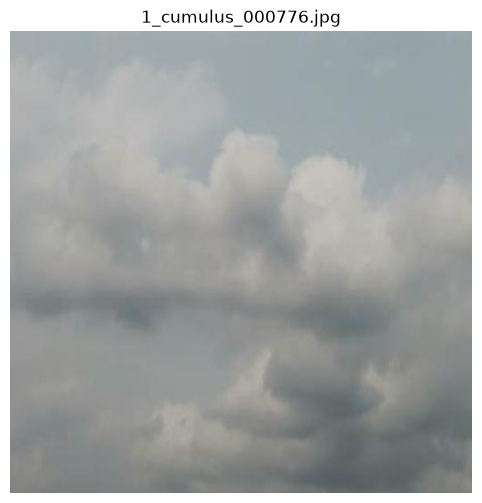

In [23]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title(test_image_path.name)
plt.axis("off")
plt.show()